In [7]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [8]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [9]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [10]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [11]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2: Return a list of legal action names.
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbor = (row + dr, col + dc)
            if self.in_bounds(neighbor) and self.is_free(neighbor):
                legal_actions.append(action)
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        return 1.0
        raise NotImplementedError("Complete GridProblem.action_cost")

In [12]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [13]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [14]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

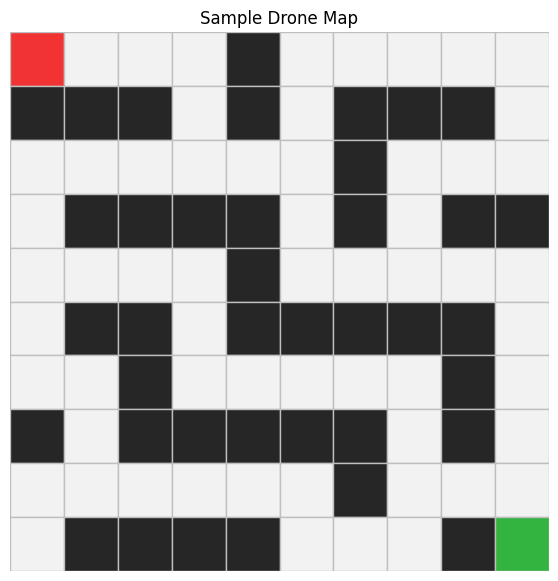

In [15]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [16]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s=node.state
        for action in problem.actions(s):
          s_prime=problem.result(s,action)
          cost=node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [17]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        start_state = problem.initial_state()
        node = Node(state=start_state)

        if problem.is_goal(node.state):
            return SearchResult(algorithm, "success", node, 0, 1, 1)

        frontier = deque([node])
        reached = {start_state}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(algorithm, "success", child, nodes_expanded, max_frontier_size, len(reached))
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))

In [22]:
# TODO 7:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        start_state=problem.initial_state()
        node=Node(state=start_state)

        if problem.is_goal(node.state):
          return  SearchResult(algorithm,"sucess",node,0,1,1)

        frontier=[node]
        reached={start_state}
        nodes_expanded=0
        max_frontier_size=1

        while frontier:
          node=frontier.pop()
          nodes_expanded +=1

          children=list(self.expand(problem,node))
          for child in reversed(children):
            s=child.state
            if problem.is_goal(s):
              return SearchResult(algorithm,"sucess",child,nodes_expanded,max_frontier_size,len(reached))
            if s not in reached:
              reached.add(s)
              frontier.append(child)
          max_frontier_size=max(max_frontier_size,len(frontier))
        return SearchResult(algorithm,"failure",None,nodes_expanded,max_frontier_size,len(reached))


In [19]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        if problem.is_goal(node.state):
            return node, "success"
        if node.depth >= limit:
            return None, "cutoff"
        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        children = list(self.expand(problem, node))
        for child in children:
            if state_is_on_path(node, child.state):
                continue
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
            result, status = self._recursive_dls(
                problem,child,limit,metrics,current_stack_size + 1
            )

            if status == "success":
                return result, "success"
            if status == "cutoff":
                cutoff_occurred = True

        return (None, "cutoff") if cutoff_occurred else (None, "failure")

In [20]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        total_nodes_expanded=0
        absolute_max_stack_size=1
        iteration_log=[]

        dls_solver = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls_solver.search(problem, limit=limit)
            total_nodes_expanded += result.nodes_expanded
            absolute_max_stack_size = max(absolute_max_stack_size, result.max_frontier_size)

            iteration_log.append({"limit": limit, "status": result.status})

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=absolute_max_stack_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log)

            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=absolute_max_stack_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log)

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=absolute_max_stack_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log
        )
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [23]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,sucess,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


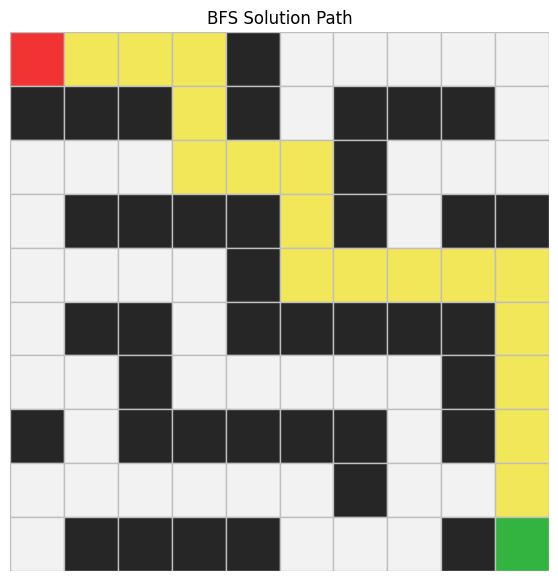

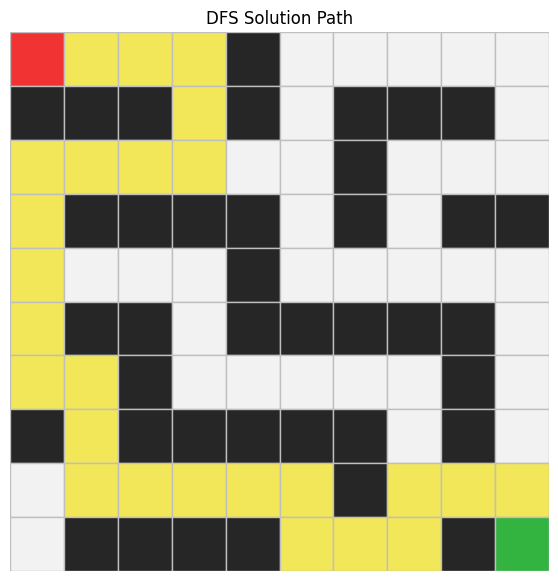

In [24]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

 Custom Map 1 Metrics 


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,20.0,20.0,51,5,51
1,DFS,sucess,NaN,20.0,20.0,20,2,21
2,DLS,cutoff,12.0,NaN,NaN,89,13,0
3,IDS,success,20.0,20.0,20.0,15198,21,0


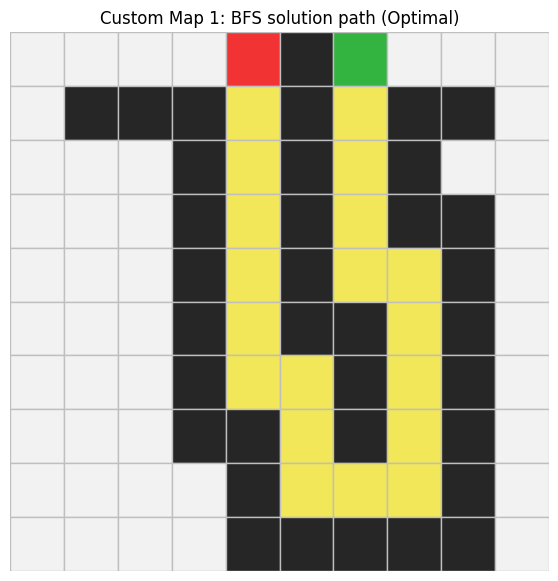

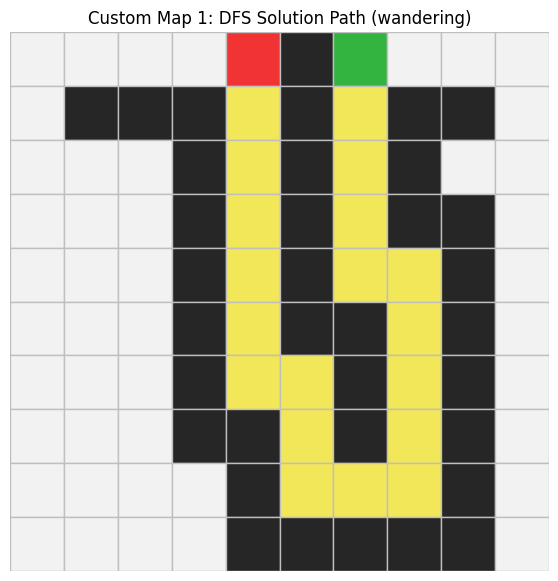

In [25]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
]

custom_start_1 = (0,4) #will start right next to the central wall partition
custom_goal_1 = (0,6) #Goal is on the other side of the partition

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=12),  # shallow limit that tests cutoff
    ids.search(custom_problem_1, max_depth = 40),
]


print(" Custom Map 1 Metrics ")
display(show_results(custom_results_1))

plot_path (
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="Custom Map 1: BFS solution path (Optimal)",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="Custom Map 1: DFS Solution Path (wandering)",
)

 Custom Map 2 Metrics 


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,48.0,48.0,117,6,118
1,DFS,sucess,NaN,54.0,54.0,59,6,63
2,DLS,cutoff,20.0,NaN,NaN,61,21,0
3,IDS,success,48.0,48.0,48.0,4686,49,0


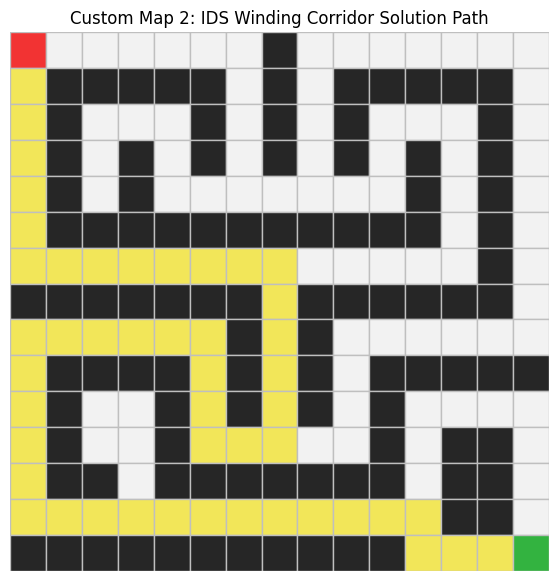

In [33]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0,1,0,1,1,1,1,1,0],
    [0,1,0,0,0,1,0,1,0,1,0,0,0,1,0],
    [0,1,0,1,0,1,0,1,0,1,0,1,0,1,0],
    [0,1,0,1,0,0,0,0,0,0,0,1,0,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],
    [1,1,1,1,1,1,1,0,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,1,0,1,0,0,0,0,0,0],
    [0,1,1,1,1,0,1,0,1,0,1,1,1,1,1],
    [0,1,0,0,1,0,1,0,1,0,1,0,0,0,0],
    [0,1,0,0,1,0,0,0,0,0,1,0,1,1,0],
    [0,1,1,0,1,1,1,1,1,1,1,0,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],]


custom_start_2 = (0,0)
custom_goal_2 = (14,14)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
   bfs.search(custom_problem_2),
   dfs.search(custom_problem_2),
   dls.search(custom_problem_2, limit=20), #which is too short for the path length
   ids.search(custom_problem_2, max_depth=60),]


print(" Custom Map 2 Metrics ")
display(show_results(custom_results_2))

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    title="Custom Map 2: IDS Winding Corridor Solution Path",)

**15.1 **
1. What is a state in this lab?
 This represents the exact physical state of the drone on th grid at any moment in time.

2. What is an action?
 An action represents movement direction that the drone can take from its current state to transition to an adjacent cell. Here, he available options are: "UP", "DOWN", "LEFT", "RIGHT".

3. What does the result function do?
 It acts as a transition model of our environment. It takes the current state and chosen action as inputs, maps it and reutrurns the new state thje drone arrives at.

 4. Why it's useful to separate the problem definition from the search algorithm?
 To enforce modularity and allow us to reuse the same BFS or IDS class to solve a grid map or maze etc by just passing a diffrent object into it.

**15.2**
1. Why does BFS use a FIFO?
This is because it expands nodes horizontally according to their proximity to the start node before proceeding to lower levels.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
Because it explores the search tree one layer after the other so it is guanteed to reach the goal with a minimum number of steps.

3. What role does the reached set play in BFS?
Acts as a memory graph filter that keeps track of every state that has already been generated or visited. Checks a child node before addition and if state is already present it is discarded.

**15.3**
1. Why does DFS use a stack?
This is because it makes use of the LIFO priority queue data structure, so explores nodes vertically first.

2. Is DFS guaranteed to find the shortest path?
No it doesnt always find the shortest path because it is still an unsupervised method so moves blindly down a specfoic branch at a time. Can even end up in an infinite loop at times.

3. Under what conditions can DFS use less memory than BFS?
BFS has larger space complexity and must retain an entire layer of the tree in memory simultanously, while DFS only needs to store the active path from the root down to the current node.

4.Under what conditions can DFS perform badly?
- The state space contains deep or infinite paths without a goal
- The goal is shallow but located on the far right of the tree, DFS could take a while to get here.



**15.4**
1. What happens when the depth limit is too small?
DLS would fsil to find a solution as it will go through all paths till hits the wall of the limit and terminate; returning a cutoff status.

2. What is the emaning of "\cutoff\"?
Simply means the search terminated without findinga goal because it encountered the depth limit boundary.

3. How is DLS different from ordinary DFS?
They operate in the same way just that DFS places a limit at a specific level where remaining child nodes can not be explored.

4. Why do we use path-cycle checking in DLS?
To checkl if a state appears along the current active branch from the root. Also prevents loops.

**15.5**
1. Why does IDS repeat DLS with increasing limits?
Because it behaves incrementally from 0 upwards to combinw the space efficiency of DFS and completeness of BFS.

2. Why can IDS be complete even though DLS with a small limit is not?
Sometimes the set limit can block DLS from getting to the goal while IDS guarantees completeness in finite state spaces.

3. Why does IDS use less memory than BFS?
BFS saves every node across a ehole frontier wave while tranversing, IDS uses depth first so only stores active path and localized siblings.

4. What is the cost of repeatedly searching from the root? wastes time.

**15.6**

1. In a real drone application, what might make one route safer or more practical?
- The weather: Sheltered paths would be preferred.
- Connectivity- We need to keep tracking the GPS

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves?
I would choose BFS. all things being equal theres assured completeness and it is quicker than the expansion of several generations of nodes.

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search?
DLS

4. What limitations does this grid model have compared with real drone navigation?
-  Can only move UP, DOWN, LEFT & RIGHT.
- Does not consider acceleration and obstacles like wind resistance.